In [2]:
import math, random, time, numpy as np, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import mne
from mne.datasets import eegbci
import matplotlib.pyplot as plt
from datetime import datetime

%load_ext autoreload
%autoreload 2 

mne.set_log_level("ERROR")
# ---------- reproducibility ----------
RANDOM_STATE = 60
def set_seeds(seed=RANDOM_STATE):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seeds()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in uso:", DEVICE)

Device in uso: cuda


In [3]:
# ================================================================
# 1) COSTANTI GLOBALI
# ================================================================
# Dati / protocollo
N_CHANNELS          = 64
SAMPLING_FREQ       = 160
EVENT_DURATION_SEC  = 4.0          # durata epoch “macro”
ALL_SUBJECTS        = [s for s in range(1, 110)
                       if s not in (89, 92, 100, 104)]

# Architettura
N_BRANCHES           = 4
DEPTH_PER_BRANCH     = 2
START_KERNEL_SIZE    = 15
KERNEL_INCREMENT     = 2

LSTM_HIDDEN_SIZE     = 768
CLASSIFIER_HIDDEN_DIM= 384


# Frequency Ablation

In [5]:
from datasets import SyntheticEEGDataset

ds = SyntheticEEGDataset(
    n_samples  = 50,                        # per classe
    labels     = ['LEFT','RIGHT','FEET','REST'],
    freq_map   = {
        'LEFT'  : (8, 13),                        # sinusoide pura a 10 Hz
        'RIGHT' : (8, 13),                        # somma di freq casuali in [15,25] Hz
        'FEET'  : (8, 13),                        # somma di 8+12+20 Hz
        'REST'  : (8, 13),                        # molto lenta
    },
    window_sec = 0.5,
    sfreq      = 160,
    noise_std  = 0.05,
    n_channels = 64,
)

loader = DataLoader(ds, batch_size=16, shuffle=True)
X_batch, y_batch = next(iter(loader))
print(X_batch.shape)  # (16, T, C, L)

[DEBUG][Synthetic] Macro 200 | Sub 1600 | per class {'LEFT': 50, 'RIGHT': 50, 'FEET': 50, 'REST': 50}
         Shape X: torch.Size([200, 64, 640])  (n_samples*n_classes, C=64, L=640)
torch.Size([16, 64, 640])


In [6]:
from model import MultiBranchCNNLSTM

model_path = './models/model_f1_exp_LR_4s-b4.pth'

model = MultiBranchCNNLSTM(2, int(4*SAMPLING_FREQ), n_branches = 4).to(DEVICE)

model.load_state_dict(torch.load(model_path))

X_batch, y_batch = next(iter(loader))

acts = model.get_activations(X_batch.unsqueeze(1).to(DEVICE))


N-Branches : 4


In [7]:
model = MultiBranchCNNLSTM(2, int(4*SAMPLING_FREQ), n_branches = 3).to(DEVICE)
model

N-Branches : 3


MultiBranchCNNLSTM(
  (branches): ModuleList(
    (0): Sequential(
      (0): ConvBlock(
        (block): Sequential(
          (0): Conv1d(64, 64, kernel_size=(15,), stride=(1,), padding=same)
          (1): GroupNorm(8, 64, eps=1e-05, affine=True)
          (2): ReLU()
          (3): Conv1d(64, 64, kernel_size=(15,), stride=(1,), padding=same)
          (4): GroupNorm(8, 64, eps=1e-05, affine=True)
          (5): ReLU()
          (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
      )
      (1): ConvBlock(
        (block): Sequential(
          (0): Conv1d(64, 64, kernel_size=(15,), stride=(1,), padding=same)
          (1): GroupNorm(8, 64, eps=1e-05, affine=True)
          (2): ReLU()
          (3): Conv1d(64, 64, kernel_size=(15,), stride=(1,), padding=same)
          (4): GroupNorm(8, 64, eps=1e-05, affine=True)
          (5): ReLU()
          (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
      )

In [8]:
model_path = './models/model_f1_exp_LR_4s-b4.pth'
model = MultiBranchCNNLSTM(2, int(4*SAMPLING_FREQ), n_branches = 4).to(DEVICE)
model.load_state_dict(torch.load(model_path))

res = []

for freq in [ (8), (13), (20), (30) ]:

    ds = SyntheticEEGDataset(
        n_samples  = 50,                        # per classe
        labels     = ['LEFT','RIGHT','FEET','REST'],
        freq_map   = {
            'LEFT'  : freq,                        # sinusoide pura a 10 Hz
            'RIGHT' : freq,                        # somma di freq casuali in [15,25] Hz
            'FEET'  : freq,                        # somma di 8+12+20 Hz
            'REST'  : freq,                        # molto lenta
        },
        window_sec = 4,
        sfreq      = 160,
        noise_std  = 0,
        n_channels = 64,
    )

    loader = DataLoader(ds, batch_size=50*4, shuffle=False)


    X_batch, _ = next(iter(loader))

    with torch.no_grad():
        acts = model.get_activations(X_batch.unsqueeze(1).to(DEVICE))
        # acts: (B, 1, n_feat, n_branches)

        # media su B e n_feat → (n_branches,)
        avg_act = acts.squeeze(1).mean(dim=(0, 1))  # (n_branches,)

        # attivazione relativa per branch → somma a 1
        rel_act = avg_act / avg_act.sum()

    res.append({'freq': freq, 'rel_act': rel_act.cpu().numpy()})
    print(f"freq={freq:3d}Hz | " + " | ".join(
        f"branch{i+1}: {v:.3f}" for i, v in enumerate(rel_act.cpu().numpy())
    ))



N-Branches : 4
[DEBUG][Synthetic] Macro 200 | Sub 200 | per class {'LEFT': 50, 'RIGHT': 50, 'FEET': 50, 'REST': 50}
         Shape X: torch.Size([200, 64, 640])  (n_samples*n_classes, C=64, L=640)
freq=  8Hz | branch1: 0.259 | branch2: 0.191 | branch3: 0.265 | branch4: 0.286
[DEBUG][Synthetic] Macro 200 | Sub 200 | per class {'LEFT': 50, 'RIGHT': 50, 'FEET': 50, 'REST': 50}
         Shape X: torch.Size([200, 64, 640])  (n_samples*n_classes, C=64, L=640)
freq= 13Hz | branch1: 0.257 | branch2: 0.197 | branch3: 0.263 | branch4: 0.283
[DEBUG][Synthetic] Macro 200 | Sub 200 | per class {'LEFT': 50, 'RIGHT': 50, 'FEET': 50, 'REST': 50}
         Shape X: torch.Size([200, 64, 640])  (n_samples*n_classes, C=64, L=640)
freq= 20Hz | branch1: 0.257 | branch2: 0.196 | branch3: 0.263 | branch4: 0.284
[DEBUG][Synthetic] Macro 200 | Sub 200 | per class {'LEFT': 50, 'RIGHT': 50, 'FEET': 50, 'REST': 50}
         Shape X: torch.Size([200, 64, 640])  (n_samples*n_classes, C=64, L=640)
freq= 30Hz | branch1

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_kernel_fft(model, sfreq=160):
    """
    Per ogni branch, estrae i kernel del primo layer conv,
    ne calcola la FFT e plotta la risposta in frequenza media.
    """
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    
    for branch_idx, (ax, branch) in enumerate(zip(axes, model.branches)):
        
        kernel = model.branches[branch_idx][0].block[0].weight.data.cpu().numpy()
        
        if kernel.ndim == 4:
            kernel = kernel.squeeze(2)  # → (out_ch, in_ch, kernel_size)
        
        # FFT su ogni kernel e media
        fft_mag = np.abs(np.fft.rfft(kernel, axis=-1))  # (out_ch, in_ch, freq_bins)
        fft_mag = fft_mag.mean(axis=(0, 1))              # (freq_bins,)
        
        freqs = np.fft.rfftfreq(kernel.shape[-1], d=1/sfreq)
        
        ax.plot(freqs, fft_mag)
        ax.set_title(f'Branch {branch_idx+1} (k={kernel.shape[-1]})')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('FFT Magnitude')
        ax.set_xlim(0, 50)
        ax.set_ylim(0.06, 0.1)
        ax.grid(True)
    
    plt.suptitle('Frequency reponse for each kernel of each branch')
    plt.tight_layout()
    plt.show()

model_path = './models/model_f1_exp_LR_4s-b4.pth'
model = MultiBranchCNNLSTM(2, int(4*SAMPLING_FREQ), n_branches = 4).to(DEVICE)
model.load_state_dict(torch.load(model_path))
plot_kernel_fft(model)

TypeError: MultiBranchCNNLSTM.__init__() got an unexpected keyword argument 'n_branches'

N-Branches : 4


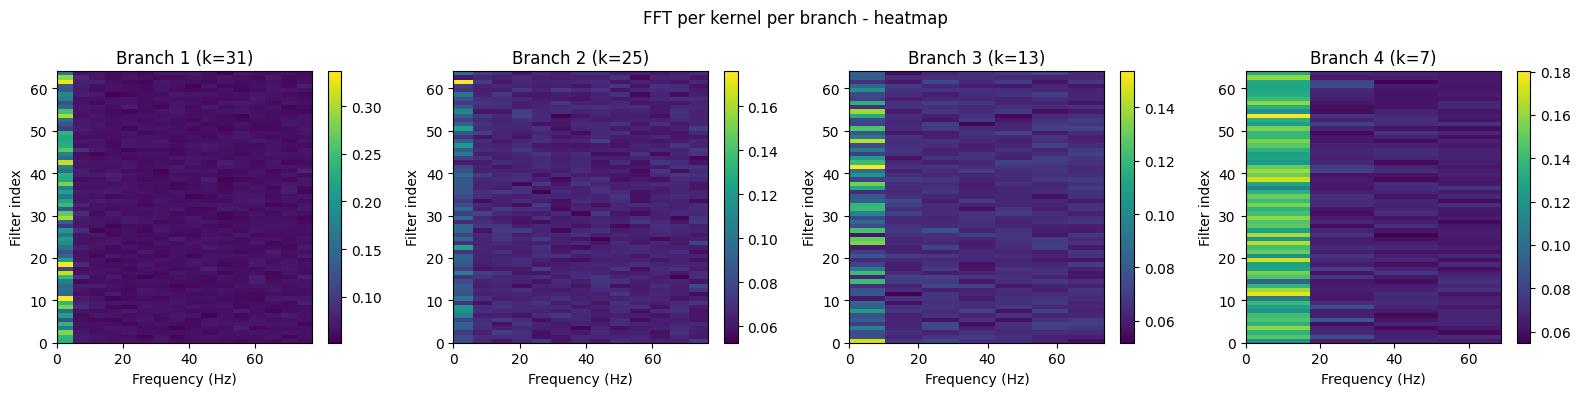

N-Branches : 4


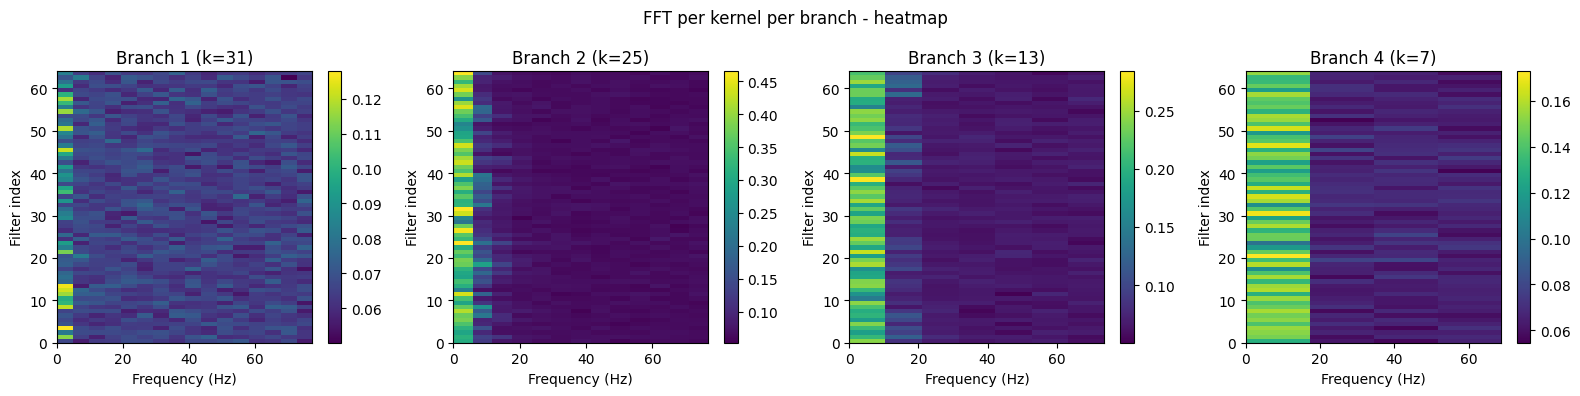

N-Branches : 4


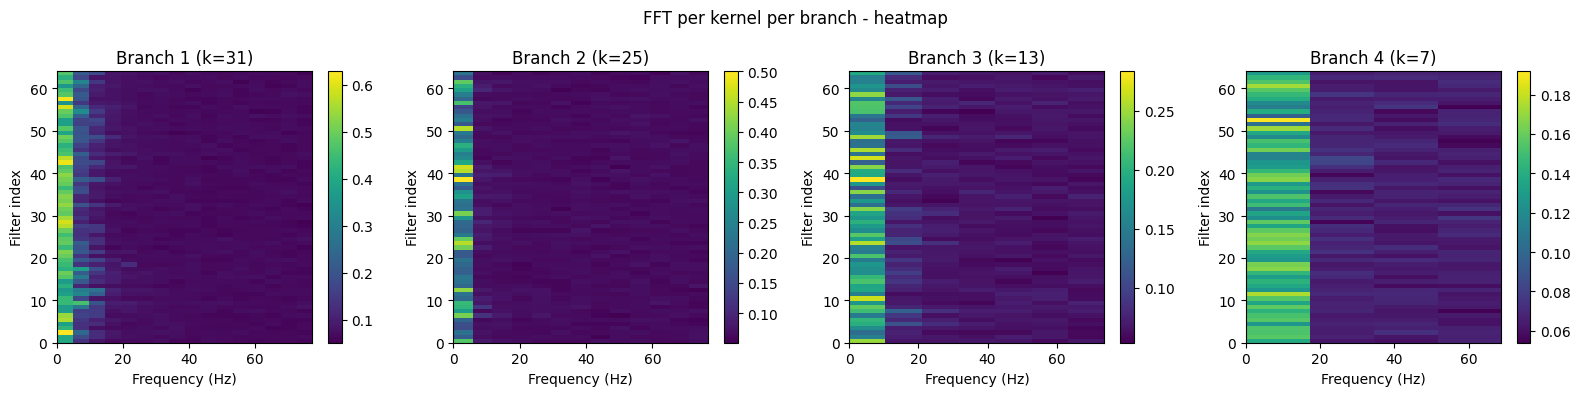

N-Branches : 4


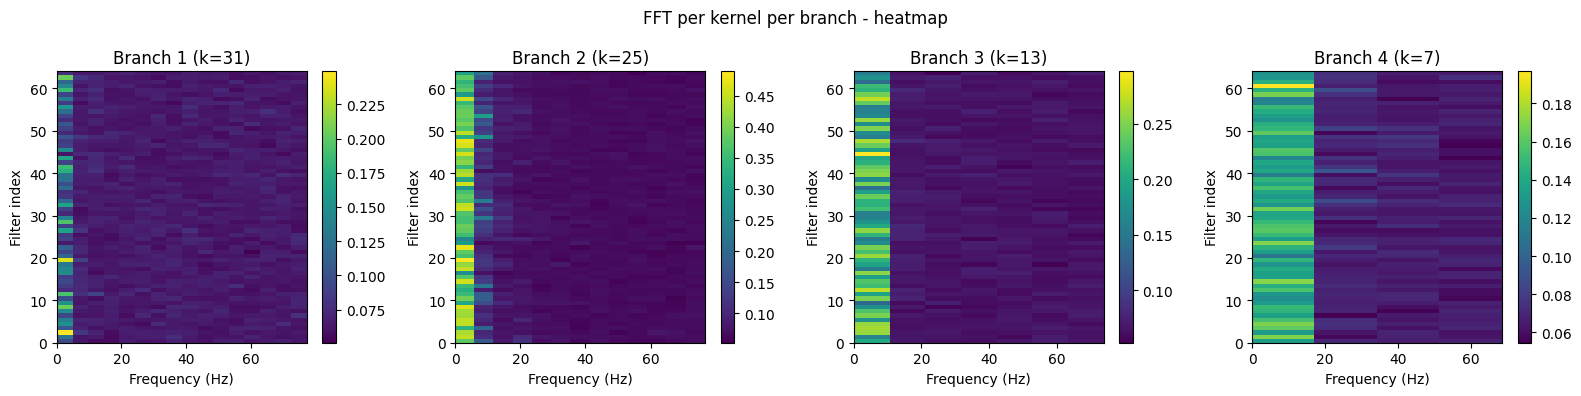

N-Branches : 4


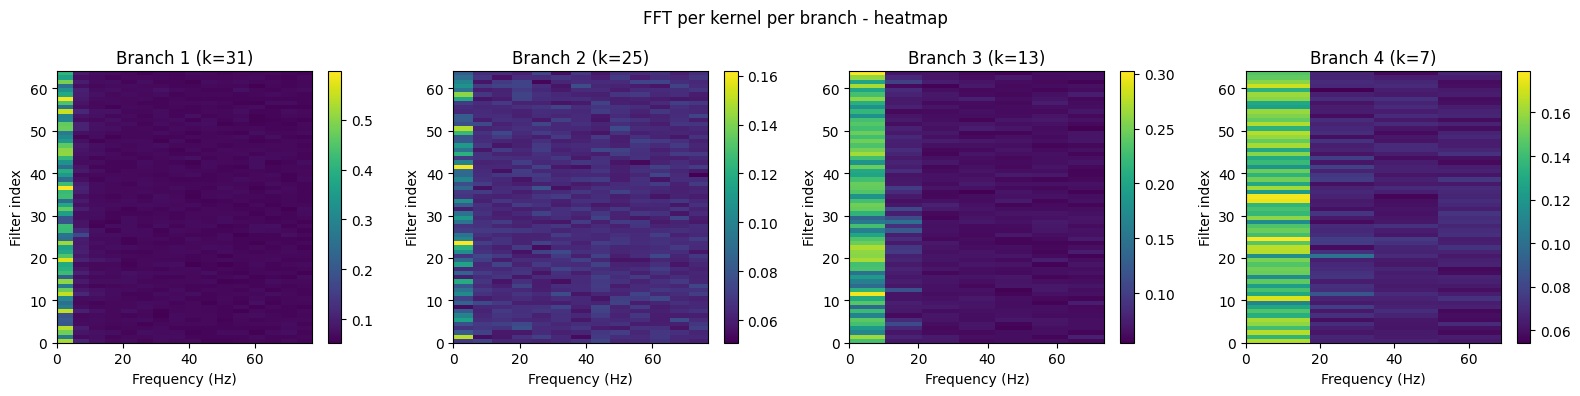

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from model import MultiBranchCNNLSTM


def plot_kernel_fft_heatmap(model, sfreq=160):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    for branch_idx, ax in enumerate(axes):
        kernel = model.branches[branch_idx][0].block[0].weight.data.cpu().numpy()
        if kernel.ndim == 4:
            kernel = kernel.squeeze(2)  # (out_ch, in_ch, kernel_size)
        
        freqs = np.fft.rfftfreq(kernel.shape[-1], d=1/sfreq)
        fft_mag_all = np.abs(np.fft.rfft(kernel, axis=-1)).mean(axis=1)  # (out_ch, freq_bins)
        
        im = ax.imshow(fft_mag_all, aspect='auto', 
                       extent=[freqs[0], freqs[-1], 0, fft_mag_all.shape[0]],
                       origin='lower', cmap='viridis')
        plt.colorbar(im, ax=ax)
        ax.set_title(f'Branch {branch_idx+1} (k={kernel.shape[-1]})')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Filter index')
    
    plt.suptitle('FFT per kernel per branch - heatmap')
    plt.tight_layout()
    plt.show()

for i in range(5):
    model_path = f'./models/model_f{i+1}_exp_LR0F_4s-b4.pth'
    model = MultiBranchCNNLSTM(4, int(4*SAMPLING_FREQ), kernel_list=[31,25,13,7]).to(DEVICE)
    # print(model)
    model.load_state_dict(torch.load(model_path))
    plot_kernel_fft_heatmap(model)

N-Branches : 4
N-Branches : 4
N-Branches : 4
N-Branches : 4
N-Branches : 4


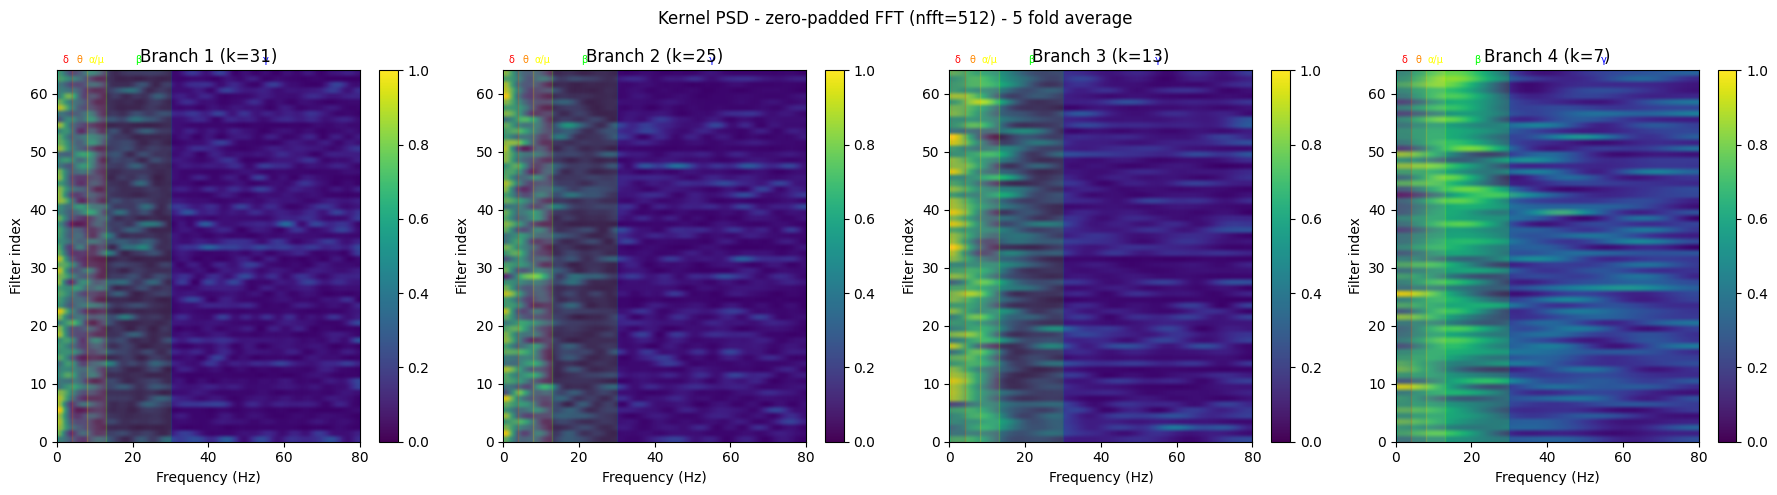

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from model import MultiBranchCNNLSTM

def plot_kernel_psd_heatmap(models, sfreq=160, nfft=512):
    """
    nfft >> kernel_size → zero-padding → risoluzione frequenziale fine
    per tutti i branch indipendentemente dal kernel size.
    """
    kernel_sizes = [31, 25, 13, 7]
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    
    bands = {'δ':(0.5,4), 'θ':(4,8), 'α/μ':(8,13), 'β':(13,30), 'γ':(30,80)}
    band_colors = ['#ff0000','#ff8800','#ffff00','#00ff00','#0000ff']

    for branch_idx, ax in enumerate(axes):
        fft_stack = []
        for model in models:
            kernel = model.branches[branch_idx][0].block[0].weight.data.cpu().numpy()
            if kernel.ndim == 4:
                kernel = kernel.squeeze(2)  # (out_ch, in_ch, k)
            
            # media su in_ch → (out_ch, k)
            kernel_mean = kernel.mean(axis=1)
            
            # FFT con zero-padding → (out_ch, nfft//2+1)
            fft_mag = np.abs(np.fft.rfft(kernel_mean, n=nfft, axis=-1)) ** 2
            
            # normalizza per filtro
            fft_mag = (fft_mag - fft_mag.min(axis=1, keepdims=True)) / \
                      (fft_mag.max(axis=1, keepdims=True) - fft_mag.min(axis=1, keepdims=True) + 1e-8)
            fft_stack.append(fft_mag)
        
        fft_avg = np.stack(fft_stack).mean(axis=0)  # (out_ch, nfft//2+1)
        freqs = np.fft.rfftfreq(nfft, d=1/sfreq)
        
        # limita a 80 Hz
        freq_mask = freqs <= 80
        freqs_plot = freqs[freq_mask]
        fft_plot   = fft_avg[:, freq_mask]

        im = ax.imshow(fft_plot, aspect='auto',
                       extent=[freqs_plot[0], freqs_plot[-1], 0, fft_plot.shape[0]],
                       origin='lower', cmap='viridis', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax)

        # bande EEG
        for (name, (lo, hi)), color in zip(bands.items(), band_colors):
            ax.axvspan(lo, hi, alpha=0.12, color=color)
            ax.text((lo+hi)/2, fft_plot.shape[0]*1.02, name,
                    ha='center', fontsize=7, color=color)

        ax.set_title(f'Branch {branch_idx+1} (k={kernel_sizes[branch_idx]})')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Filter index')
        ax.set_xlim(0, 80)

    plt.suptitle(f'Kernel PSD - zero-padded FFT (nfft={nfft}) - 5 fold average')
    plt.tight_layout()
    plt.show()

# carica tutti i modelli
models = []
for i in range(5):
    model_path = f'./models/model_f{i+1}_exp_LR0F_4s-b4.pth'
    m = MultiBranchCNNLSTM(4, int(4*SAMPLING_FREQ), kernel_list=[31,25,13,7]).to(DEVICE)
    m.load_state_dict(torch.load(model_path))
    m.eval()
    models.append(m)

plot_kernel_psd_heatmap(models, nfft=512)

# FLOPS

In [4]:
train_ds = EEGMMIDBDataset([10], ["L","R"], "I", 4, SAMPLING_FREQ)

sample =  next(iter(train_ds))
sample[0].shape

/home/zino/Projects/EEG/MI/EEG-BCI-Cross-Subject-Motor-Imagery/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[DEBUG] Runs [4, 8, 12] | Macro 45 | Sub 45 | per class {'L': 24, 'R': 21}


torch.Size([1, 64, 640])

In [ ]:
from flop_counter import get_flops

labels = ["L","R"]
win_sec = 4

N_BRANCHES = 1
model = model = MultiBranchCNNLSTM(len(labels),
                                    int(win_sec*SAMPLING_FREQ))
flops1 = get_flops(model, (1, 1, 64, 640))

N_BRANCHES = 2
model = model = MultiBranchCNNLSTM(len(labels),
                                    int(win_sec*SAMPLING_FREQ))
flops2 = get_flops(model, (1, 1, 64, 640))

N_BRANCHES = 3
model = model = MultiBranchCNNLSTM(len(labels),
                                    int(win_sec*SAMPLING_FREQ))
flops3 = get_flops(model, (1, 1, 64, 640))

N_BRANCHES = 4
model = model = MultiBranchCNNLSTM(len(labels),
                                    int(win_sec*SAMPLING_FREQ))
flops4 = get_flops(model, (1, 1, 64, 640))

print(f"Flops:\n1: {flops1}\n2: {flops2}\n3: {flops3}\n4: {flops4}")

/home/zino/Projects/EEG/MI/EEG-BCI-Cross-Subject-Motor-Imagery/flop_counter.py:14: UserWarning: mods argument is not needed anymore, you can stop passing it
  flop_counter = FlopCounterMode(mods=model, display=False, depth=None)


Flops:
 1: 236520960
2: 504497664
3: 803931648
4: 1134822912


In [ ]:
# ================================================================
# 7) EXPERIMENT LIST
# ================================================================
EXPERIMENTS = [
    # ---------- Sub-Window = 4 s (seq_len = 1) ----------------------------
    ("exp_LR_4s",     ["L","R"],                      "I", 4, 5),
    ("exp_LR0_4s",    ["L","R","0"],                  "I", 4, 5),
    ("exp_LR0F_4s",   ["L","R","0","F"],              "I", 4, 5),
    ("exp_LR0FB_4s",  ["L","R","0","F","B"],          "I", 4, 5),

    # ---------- Sub-Window = 2 s (seq_len = 2) ----------------------------
    ("exp_LR_2s",     ["L","R"],                      "I", 2, 5),
    ("exp_LR0_2s",    ["L","R","0"],                  "I", 2, 5),
    ("exp_LR0F_2s",   ["L","R","0","F"],              "I", 2, 5),
    ("exp_LR0FB_2s",  ["L","R","0","F","B"],          "I", 2, 5),

    # ---------- Sub-Window = 1 s (seq_len = 4) – mode I --------------
    ("exp_LR_1s_I",    ["L","R"],                     "I", 1, 5),
    ("exp_LR0_1s_I",   ["L","R","0"],                 "I", 1, 5),
    ("exp_LR0F_1s_I",  ["L","R","0","F"],             "I", 1, 5),
    ("exp_LR0FB_1s_I", ["L","R","0","F","B"],         "I", 1, 5),
    ("exp_BF_1s_I",    ["B","F"],                     "I", 1, 5),
    ("exp_BF0_1s_I",   ["B","F","0"],                 "I", 1, 5),

    # ---------- Sub-Window = 1 s – mode B (Both) ---------------------
    ("exp_LR_1s_B",    ["L","R"],                     "B", 1, 5),
    ("exp_LR0_1s_B",   ["L","R","0"],                 "B", 1, 5),
    ("exp_LR0F_1s_B",  ["L","R","0","F"],             "B", 1, 5),
    ("exp_LR0FB_1s_B", ["L","R","0","F","B"],         "B", 1, 5),

    # ---------- Sub-Window = 1 s – mode R (Real) ---------------------
    ("exp_LR_1s_R",    ["L","R"],                     "R", 1, 5),
    ("exp_LR0_1s_R",   ["L","R","0"],                 "R", 1, 5),
    ("exp_LR0F_1s_R",  ["L","R","0","F"],             "R", 1, 5),
    ("exp_LR0FB_1s_R", ["L","R","0","F","B"],         "R", 1, 5),

    # ---------- Sub-Window = 1 s – LOSO (leave-one-subject-out) ----------
    ("exp_LR0_1s_LOSO", ["L","R","0"],                "I", 1, 105),

    # ---------- Sub-Window = 0.5 s (seq_len = 8) -------------------------
    ("exp_LR_05s",     ["L","R"],                     "I", 0.5, 5),
    ("exp_LR0_05s",    ["L","R","0"],                 "I", 0.5, 5),
    ("exp_LR0F_05s",   ["L","R","0","F"],             "I", 0.5, 5),
    ("exp_LR0FB_1s_R", ["L","R","0","F","B"],         "R", 0.5, 5),
]


In [ ]:
# ================================================================
# 8) LANCIO
# ================================================================
for name, labels, mode, win, folds in EXPERIMENTS:
    set_seeds()                     # reset RNG
    Experiment(name, labels, mode, win, folds).run(ALL_SUBJECTS)


In [ ]:
df

,experiment,acc_mean,acc_std,fold_1,fold_2,fold_3,fold_4,fold_5,fold_6,fold_7,...,fold_96,fold_97,fold_98,fold_99,fold_100,fold_101,fold_102,fold_103,fold_104,fold_105
13,exp_BF0_1s_I,0.702,0.021,0.712659,0.715024,0.691402,0.666010,0.726077,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,exp_BF_1s_I,0.739,0.018,0.732503,0.762473,0.733862,0.711498,0.755876,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,exp_LR0FB_1s_B,0.690,0.015,0.687243,0.696393,0.671362,0.680423,0.713757,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,exp_LR0FB_1s_I,0.676,0.015,0.680831,0.687053,0.670304,0.649829,0.692231,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,exp_LR0FB_1s_R,0.672,0.019,0.657444,0.684050,0.651587,0.662336,0.703142,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,exp_LR0FB_2s,0.678,0.015,0.696585,0.677047,0.675529,0.651666,0.689509,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,exp_LR0FB_4s,0.670,0.025,0.689171,0.675325,0.655820,0.629494,0.697742,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,exp_LR0F_05s,0.735,0.013,0.734644,0.737262,0.726241,0.718600,0.756751,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,exp_LR0F_1s_B,0.749,0.014,0.749659,0.752045,0.734887,0.737335,0.772921,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,exp_LR0F_1s_I,0.738,0.017,0.743268,0.742516,0.723593,0.715528,0.763122,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df

,Soggetti,Classi,Compito (I/R),Tipo classi,Validation,Finestre,Accuracy
0,103,2,I,L/R,cross 5 fold,4.0s,83.40% ± 2.10%
1,103,3,I,L/R/0,cross 5 fold,4.0s,75.80% ± 2.30%
2,103,4,I,L/R/0/F,cross 5 fold,4.0s,74.40% ± 1.50%
3,103,5,I,L/R/0/F/B,cross 5 fold,4.0s,67.00% ± 2.50%
4,103,2,I,L/R,cross 5 fold,2.0s,83.30% ± 2.30%
5,103,3,I,L/R/0,cross 5 fold,2.0s,75.50% ± 2.00%
6,103,4,I,L/R/0/F,cross 5 fold,2.0s,74.20% ± 1.90%
7,103,5,I,L/R/0/F/B,cross 5 fold,2.0s,67.80% ± 1.50%
8,103,2,I,L/R,cross 5 fold,1.0s,82.80% ± 2.20%
9,103,3,I,L/R/0,cross 5 fold,1.0s,75.10% ± 1.90%


In [5]:
from torchsummary import summary
from model import MultiBranchCNNLSTM

m = MultiBranchCNNLSTM(4, int(4*160), kernel_list=[31,25,13,7])

print(m)

N-Branches : 4
MultiBranchCNNLSTM(
  (branches): ModuleList(
    (0): Sequential(
      (0): ConvBlock(
        (block): Sequential(
          (0): Conv1d(64, 64, kernel_size=(31,), stride=(1,), padding=same)
          (1): GroupNorm(8, 64, eps=1e-05, affine=True)
          (2): ReLU()
          (3): Conv1d(64, 64, kernel_size=(31,), stride=(1,), padding=same)
          (4): GroupNorm(8, 64, eps=1e-05, affine=True)
          (5): ReLU()
          (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
      )
      (1): ConvBlock(
        (block): Sequential(
          (0): Conv1d(64, 64, kernel_size=(31,), stride=(1,), padding=same)
          (1): GroupNorm(8, 64, eps=1e-05, affine=True)
          (2): ReLU()
          (3): Conv1d(64, 64, kernel_size=(31,), stride=(1,), padding=same)
          (4): GroupNorm(8, 64, eps=1e-05, affine=True)
          (5): ReLU()
          (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  